<div style="font-family: 'Times New Roman', serif; text-align: center; padding: 20px 0;">

<hr style="border: none; border-top: 1px solid #444;">

<p style="font-size: 13px; letter-spacing: 3px; color: #666; margin: 15px 0 8px 0;">
PATCH COMPOSITION
</p>

<p style="font-size: 32px; font-weight: bold; margin: 0 0 15px 0;">
Radial Evolution
</p>

<hr style="border: none; border-top: 1px solid #444; width: 80%;">

</div>

In [22]:
""" Import Modules """
import numpy             as np
import pandas            as pd
import xarray            as xr
import speasy            as spz
import matplotlib.pyplot as plt

from pathlib            import Path
from datetime           import datetime, timedelta
from matplotlib.patches import Rectangle

In [18]:
""" Import catalog """
file_path = Path('..') / "Results/patch_catalog.nc"

patch_catalog = xr.open_dataset(file_path).to_dataframe()

patch_catalog

,spacecraft,date_start,date_end,duration,r_min,r_max,number,id
index,,,,,,,,
0,Parker Solar Probe,2025-09-12 00:00:00,2025-09-17 00:00:00,432000.0,0.045881,0.211670,1,PSP-001
1,Parker Solar Probe,2024-12-24 00:00:00,2024-12-29 00:00:00,432000.0,0.045881,0.236100,2,PSP-002
2,Parker Solar Probe,2025-03-18 00:00:00,2025-03-27 00:00:00,777600.0,0.045887,0.251621,3,PSP-003
3,Parker Solar Probe,2024-09-29 13:00:00,2024-10-04 00:00:00,385200.0,0.053187,0.205197,4,PSP-004
4,Parker Solar Probe,2024-03-30 00:00:00,2024-04-04 00:00:00,432000.0,0.053190,0.245669,5,PSP-005
5,Parker Solar Probe,2024-06-30 14:00:00,2024-07-01 14:00:00,86400.0,0.060646,0.104399,6,PSP-006
6,Parker Solar Probe,2022-05-26 00:00:00,2022-06-02 00:00:00,604800.0,0.061755,0.305498,7,PSP-007
7,Parker Solar Probe,2022-02-20 00:00:00,2022-03-03 00:00:00,950400.0,0.061759,0.265646,8,PSP-008
8,Parker Solar Probe,2021-11-19 00:00:00,2021-11-22 00:00:00,259200.0,0.061761,0.144468,9,PSP-009


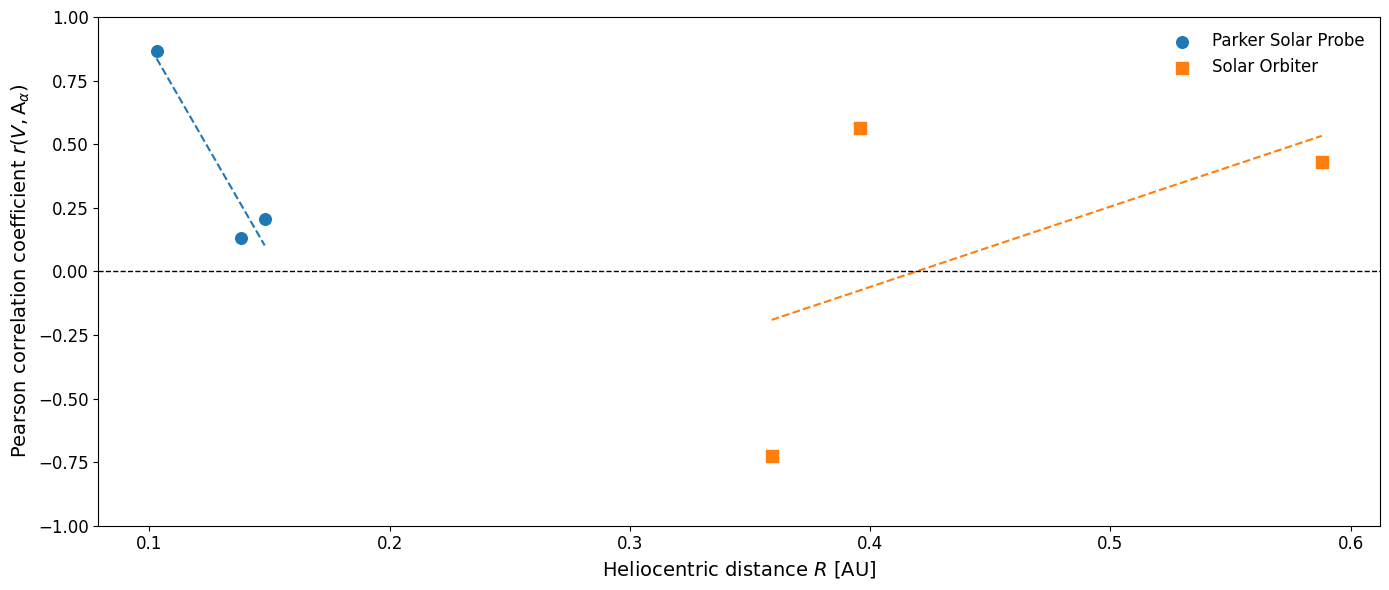

In [36]:
""" Parker Solar Probe """
R_psp = np.array([
    0.103, 0.148, 0.138,
])

r_psp = np.array([
    0.867, 0.207, 0.130,
])

""" Solar Orbiter """
R_solo = np.array([
    0.359, 0.588, 0.396,
])

r_solo = np.array([
    -0.724, 0.43, 0.562,
])

# Linear fit
fit_psp = np.polyfit(R_psp, r_psp, 1)
fit_solo = np.polyfit(R_solo, r_solo, 1)

R_fit_psp = np.linspace(R_psp.min(), R_psp.max(), 100)
R_fit_solo = np.linspace(R_solo.min(), R_solo.max(), 100)

r_fit_psp = np.polyval(fit_psp, R_fit_psp)
r_fit_solo = np.polyval(fit_solo, R_fit_solo)

fig, ax = plt.subplots(figsize=(14, 6))

ax.scatter(
    R_psp,
    r_psp,
    s=70,
    marker="o",
    label="Parker Solar Probe"
)

ax.scatter(
    R_solo,
    r_solo,
    s=70,
    marker="s",
    label="Solar Orbiter"
)

ax.plot(
    R_fit_psp,
    r_fit_psp,
    linestyle="--",
    linewidth=1.5
)

ax.plot(
    R_fit_solo,
    r_fit_solo,
    linestyle="--",
    linewidth=1.5
)


ax.axhline(
    0,
    color="black",
    linestyle="--",
    linewidth=1
)

ax.set_xlabel(
    r"Heliocentric distance $R$ [AU]",
    fontsize=14
)

ax.set_ylabel(
    r"Pearson correlation coefficient $r(V,\mathrm{A}_{\alpha})$",
    fontsize=14
)

ax.set_ylim(-1, 1)

ax.tick_params(
    axis="both",
    labelsize=12
)

ax.legend(
    fontsize=12,
    frameon=False
)

plt.tight_layout()
plt.show()